# LEAF TLS – Concepts & Reference Guide

A documentation notebook for understanding the geometry, physics, and math behind terrestrial laser scanning with the LEAF instrument. Written as a lookup reference for the DE-Har processing pipeline.

**Contents:**
1. What is a Terrestrial Laser Scanner?
2. Coordinate system: zenith and azimuth angles
3. The LEAF instrument: how it moves and measures
4. Encoders: how angles are recorded
5. What the laser measures: range and intensity
6. Beam divergence and spatial resolution
7. Gap fraction: the core measurement
8. From gap fraction to Plant Area Index (PAI)
9. The hinge angle trick (57.5°)
10. Vertical profiles: PAVD
11. Uncertainty and error sources
12. Glossary

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

---
## 1. What is a Terrestrial Laser Scanner (TLS)?

A TLS is an instrument that sits on the ground (usually on a tripod) and shoots laser pulses in many directions. For each pulse it records:
- **Did the pulse hit something?** (a leaf, a branch, the ground — or nothing = open sky)
- **If yes, how far away?** (the *range*, measured via the time it takes light to travel there and back)
- **In which direction was the pulse fired?** (the *pointing direction*, described by two angles)

By firing thousands of pulses in a systematic pattern across the sky hemisphere, the scanner builds a complete picture of what is above it: where the canopy is, where the gaps are, and how vegetation is distributed vertically.

The LEAF instrument is specifically designed for **long-term vegetation monitoring** — it lives in the forest for months or years, scanning automatically on a schedule, and tracking how canopy structure changes over time.

---
## 2. Coordinate system: zenith and azimuth angles

To describe where the laser is pointing, two angles are used:

### Zenith angle (θ)
The angle measured **from straight up** (vertical). Think of it as "how far from directly overhead":
- **θ = 0°** → the laser points **straight up** (toward the sky, through the canopy)
- **θ = 45°** → halfway between up and the horizon
- **θ = 90°** → the laser points **horizontally** (at the horizon)
- **θ > 90°** → the laser points **below the horizon** (toward the ground)

The LEAF scans from 0° to 130° zenith (i.e. from straight up to 40° below the horizon).

### Azimuth angle (φ)
The **compass direction** the laser points in the horizontal plane:
- **φ = 0°** → aligned with the reference direction (typically North)
- **φ = 90°** → East
- **φ = 180°** → South
- **φ = 360°** → back to North (full circle)

Together, zenith + azimuth uniquely describe any direction in the hemisphere above (and slightly below) the scanner.

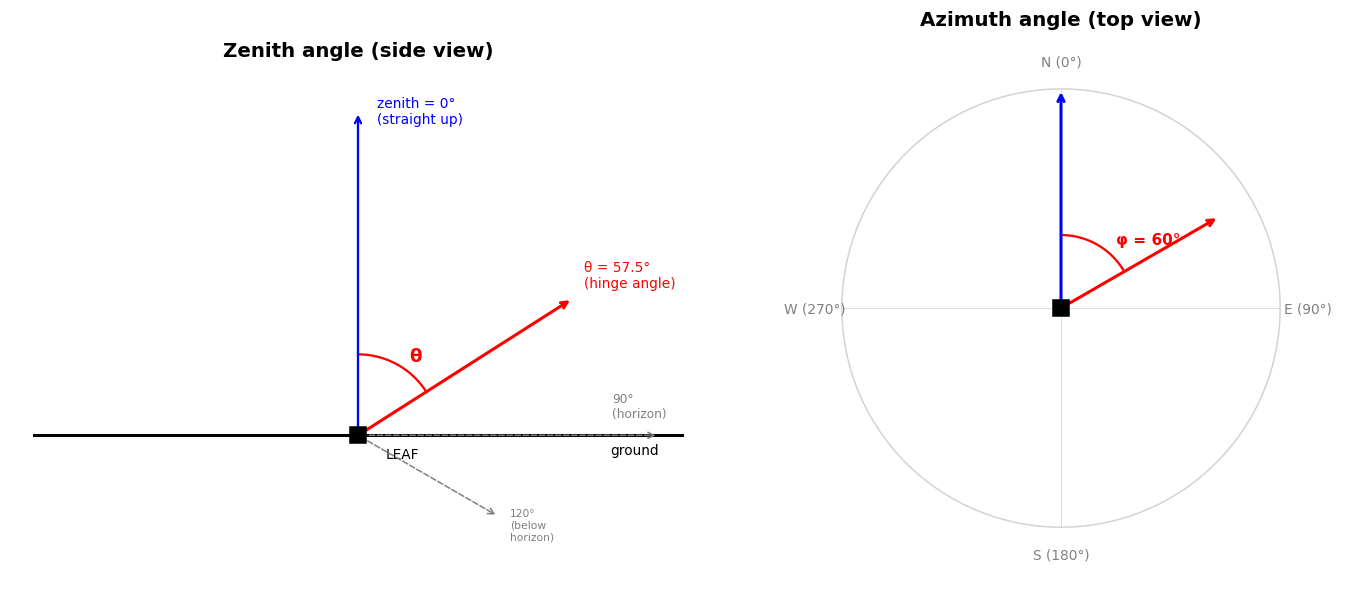

In [2]:
# --- Diagram: zenith and azimuth angles ---

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# LEFT: Side view showing zenith angle
ax = axes[0]
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-0.5, 1.6)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Zenith angle (side view)', fontsize=13, fontweight='bold')

# Ground line
ax.plot([-1.4, 1.4], [0, 0], 'k-', lw=2)
ax.text(1.3, -0.08, 'ground', fontsize=9, ha='right')

# Scanner
ax.plot(0, 0, 'ks', ms=10, zorder=5)
ax.text(0.12, -0.1, 'LEAF', fontsize=9)

# Vertical (zenith = 0)
ax.annotate('', xy=(0, 1.4), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))
ax.text(0.08, 1.35, 'zenith = 0°\n(straight up)', fontsize=9, color='blue')

# Horizon (zenith = 90)
ax.annotate('', xy=(1.3, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='grey', lw=1, ls='--'))
ax.text(1.1, 0.08, '90°\n(horizon)', fontsize=8, color='grey')

# Example beam at 57.5 deg
theta = np.radians(57.5)
bx, by = 1.1 * np.sin(theta), 1.1 * np.cos(theta)
ax.annotate('', xy=(bx, by), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(bx + 0.05, by + 0.05, 'θ = 57.5°\n(hinge angle)', fontsize=9, color='red')

# Arc showing angle
arc_theta = np.linspace(0, theta, 30)
ax.plot(0.35 * np.sin(arc_theta), 0.35 * np.cos(arc_theta), 'r-', lw=1.5)
ax.text(0.22, 0.32, 'θ', fontsize=12, color='red', fontweight='bold')

# Below horizon
theta2 = np.radians(120)
bx2, by2 = 0.7 * np.sin(theta2), 0.7 * np.cos(theta2)
ax.annotate('', xy=(bx2, by2), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='grey', lw=1, ls='--'))
ax.text(bx2 + 0.05, by2 - 0.1, '120°\n(below\nhorizon)', fontsize=7, color='grey')


# RIGHT: Top view showing azimuth angle
ax = axes[1]
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Azimuth angle (top view)', fontsize=13, fontweight='bold')

# Circle
circle = plt.Circle((0, 0), 1.2, fill=False, color='lightgrey', lw=1)
ax.add_patch(circle)

# Scanner
ax.plot(0, 0, 'ks', ms=10, zorder=5)

# Cardinal directions
for angle, label in [(90, 'N (0°)'), (0, 'E (90°)'), (270, 'S (180°)'), (180, 'W (270°)')]:
    rad = np.radians(angle)
    ax.text(1.35 * np.cos(rad), 1.35 * np.sin(rad), label,
            fontsize=9, ha='center', va='center', color='grey')
    ax.plot([0, 1.2 * np.cos(rad)], [0, 1.2 * np.sin(rad)],
            'lightgrey', lw=0.5)

# Reference direction (North = 0 azimuth)
ax.annotate('', xy=(0, 1.2), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))

# Example azimuth
phi = np.radians(60)
ax.annotate('', xy=(1.0 * np.sin(phi), 1.0 * np.cos(phi)), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
arc_phi = np.linspace(np.pi/2, np.pi/2 - phi, 30)
ax.plot(0.4 * np.cos(arc_phi), 0.4 * np.sin(arc_phi), 'r-', lw=1.5)
ax.text(0.3, 0.35, 'φ = 60°', fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3. The LEAF instrument: how it moves and measures

The LEAF has two motorized axes:

1. **Rotary table** — spins the whole sensor head around the **azimuth** axis (horizontal plane, like a turntable)
2. **Scan head** — tilts the lidar up and down around the **zenith** axis (vertical plane, like nodding)

### Scan patterns

| Scan type | How it works |
|-----------|-------------|
| **Hemispherical** | The scan head sweeps from −130° to +130° zenith. For each zenith sweep, the rotary table steps to the next azimuth position. Azimuth goes from 0° to 180° (since the ±130° zenith sweep covers both sides, a 180° azimuth rotation gives full hemispheric coverage). |
| **Hinge** | The scan head tilts to a fixed zenith angle (57.5° ± 0.9° for high-res, giving 5 rings). The rotary table then spins a full 360° at each ring. This densely samples one specific zenith angle — the one most useful for LAI estimation. |
| **Ground** | Same as hinge but pointed downward at 122.5° zenith (= 57.5° below nadir). Used for monitoring ground cover. |

### The laser itself
- Wavelength: **905 nm** (near-infrared, invisible to the eye)
- Measurement: **time-of-flight** — the instrument measures how long it takes a laser pulse to travel to a target and back
- Range: up to **100 m** in sunlit conditions
- Rate: **~90 samples per second**
- Each sample records a **first return** (nearest object hit) and a **last return** (furthest object, if the beam penetrates past the first)

---
## 4. Encoders: how angles are recorded

The LEAF does not directly record zenith and azimuth angles in degrees. Instead, it records **encoder counts** — integer values from internal position sensors on each motor.

### Scan encoder (zenith)
- Tracks the position of the scan head (the lidar tilt)
- Resolution: **25,600 counts per full 360° rotation**
- So 1 count = 360° / 25,600 = **0.014°**
- The encoder value is **relative to the scan start position**, not to true vertical

### Rotary encoder (azimuth)
- Tracks the position of the rotary table (the horizontal spin)
- Resolution: **20,000 counts per full 360° rotation**
- So 1 count = 360° / 20,000 = **0.018°**
- The 0° position is aligned with the antenna on the LEAF housing

### Converting encoder to angle

$$\text{angle (degrees)} = \frac{\text{encoder value}}{\text{encoder full count}} \times 360°$$

For the scan encoder, an additional **offset** must be subtracted to convert from the relative encoder position to true zenith (where 0° = straight up). This offset is calibrated by finding the midpoint of the encoder range in a hemispherical scan.

In [3]:
# --- Encoder conversion example ---

SCAN_ENC_FULL = 25600
ROTARY_ENC_FULL = 20000

# Example: scan encoder value 9080
scan_enc = 9080
raw_deg = (scan_enc / SCAN_ENC_FULL) * 360
print(f"Scan encoder {scan_enc} → raw angle: {raw_deg:.2f}°")

# If we know the encoder at true zenith is, say, 12800:
enc_at_zenith0 = 12800  # hypothetical; calibrate from data
true_zenith = (scan_enc - enc_at_zenith0) / SCAN_ENC_FULL * 360
print(f"  → true zenith: {true_zenith:.2f}° (negative = other side of hemisphere)")

# Rotary encoder 2625
rot_enc = 2625
azimuth = (rot_enc / ROTARY_ENC_FULL) * 360
print(f"\nRotary encoder {rot_enc} → azimuth: {azimuth:.2f}°")

Scan encoder 9080 → raw angle: 127.69°
  → true zenith: -52.31° (negative = other side of hemisphere)

Rotary encoder 2625 → azimuth: 47.25°


---
## 5. What the laser measures: range and intensity

For each laser pulse, the LEAF records:

### Range (metres)
The distance from the scanner to the target, measured by timing the round-trip of the laser pulse:

$$\text{range} = \frac{c \times t_{\text{round-trip}}}{2}$$

where $c$ = speed of light (~3 × 10⁸ m/s) and $t$ = round-trip time.

Special values:
- **range = −1.00** → the pulse did not hit anything (= **gap**, open sky)
- **range > 120 m** → also treated as a non-return (gap)
- Valid returns: 0 to ~100 m

The LEAF records both a **first return** (nearest object the beam encounters) and a **last return** (furthest detectable object). In a forest canopy:
- First return might be a leaf at 8 m
- Last return might be a branch behind it at 12 m

### Intensity (0–100)
A measure of how strongly the laser pulse was reflected back. 
- **0** = no return (gap)
- **100** = maximum reflectance

⚠️ Intensity values are **uncalibrated** and **not corrected for distance** (signal drops off as 1/r²). This means a leaf at 20 m will appear dimmer than the same leaf at 5 m. For the DE-Har analysis, intensity is secondary — the main products come from range and gap/no-gap classification.

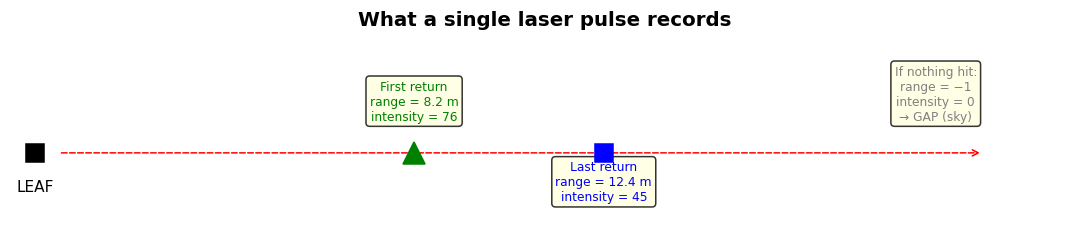

In [4]:
# --- Illustration: what a single laser pulse sees ---

fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(-0.5, 22)
ax.set_ylim(-1.5, 2.5)
ax.set_aspect('equal')
ax.axis('off')

# Scanner
ax.plot(0, 0, 'ks', ms=12)
ax.text(0, -0.8, 'LEAF', ha='center', fontsize=10)

# Laser beam
ax.annotate('', xy=(20, 0), xytext=(0.5, 0),
            arrowprops=dict(arrowstyle='->', color='red', lw=1, ls='--'))

# First return: leaf at 8m
ax.plot(8, 0, 'g^', ms=15, zorder=5)
ax.text(8, 0.7, 'First return\nrange = 8.2 m\nintensity = 76', 
        ha='center', fontsize=8, color='green',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Last return: branch at 12m
ax.plot(12, 0, 'bs', ms=12, zorder=5)
ax.text(12, -1.0, 'Last return\nrange = 12.4 m\nintensity = 45', 
        ha='center', fontsize=8, color='blue',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Gap: no return
ax.text(19, 0.7, 'If nothing hit:\nrange = −1\nintensity = 0\n→ GAP (sky)', 
        ha='center', fontsize=8, color='grey',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.set_title('What a single laser pulse records', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Beam divergence and spatial resolution

The laser beam is not a perfect infinitely thin line — it spreads out with distance. This spreading is called **beam divergence**.

### LEAF beam divergence: 0.3°

This means the beam diameter grows with distance:

$$d_{\text{beam}} = 2 \times r \times \tan\left(\frac{\alpha}{2}\right) \approx r \times \alpha_{\text{rad}}$$

where $r$ = range and $\alpha$ = beam divergence.

| Range | Beam diameter |
|-------|---------------|
| 1 m   | 0.5 cm |
| 5 m   | 2.6 cm |
| 10 m  | 5.2 cm |
| 20 m  | 10.5 cm |
| 50 m  | 26.2 cm |

### What this means in practice

- At close range (< 5 m), the beam is narrow enough to resolve individual small branches
- At canopy height (~15–20 m at DE-Har), the beam is about **8–10 cm wide** — comparable to a leaf size. A single pulse might partially hit a leaf and partially pass through → the returned intensity will be lower (a "partial hit")
- At long range (> 30 m), the beam is wide enough to straddle multiple objects

### Angular resolution

The angular step between consecutive measurements:
- **Hemi-hi**: 0.45° step → at 15 m range, consecutive samples are ~12 cm apart
- **Hemi-low**: 1.8° step → at 15 m range, consecutive samples are ~47 cm apart
- **Hinge**: 0.042° azimuth step → at 15 m range, ~1.1 cm apart along the ring

The LEAF is a **low spatial resolution** TLS — it trades spatial detail for temporal coverage (many scans per day over long periods).

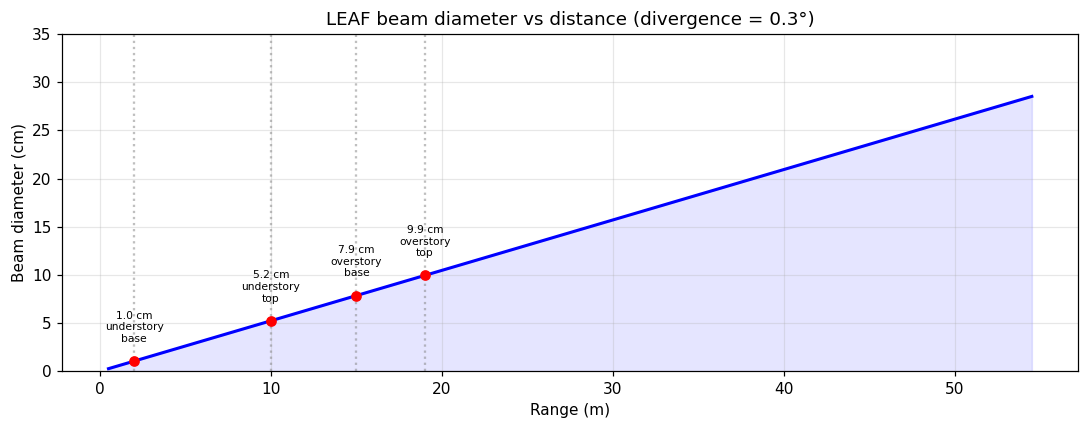

In [5]:
# --- Beam divergence with distance ---

divergence_deg = 0.3
divergence_rad = np.radians(divergence_deg)
ranges = np.arange(0.5, 55, 0.5)
beam_diameter_cm = 2 * ranges * np.tan(divergence_rad / 2) * 100  # cm

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ranges, beam_diameter_cm, 'b-', lw=2)
ax.fill_between(ranges, 0, beam_diameter_cm, alpha=0.1, color='blue')

# Mark key distances
for r, label in [(2, 'understory\nbase'), (10, 'understory\ntop'), 
                  (15, 'overstory\nbase'), (19, 'overstory\ntop')]:
    d = 2 * r * np.tan(divergence_rad / 2) * 100
    ax.axvline(r, color='grey', ls=':', alpha=0.5)
    ax.plot(r, d, 'ro', ms=6)
    ax.text(r, d + 2, f'{d:.1f} cm\n{label}', fontsize=7, ha='center')

ax.set(xlabel='Range (m)', ylabel='Beam diameter (cm)',
       title=f'LEAF beam diameter vs distance (divergence = {divergence_deg}°)')
ax.set_ylim(0, 35)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Gap fraction: the core measurement

Gap fraction is the single most important quantity derived from TLS data. It answers:

> *"If I look in direction θ (zenith angle), what fraction of the sky is visible through the canopy?"*

### Definition

$$P_{gap}(\theta) = \frac{\text{number of laser shots that hit nothing (gaps)}}{\text{total number of laser shots}}$$

evaluated per **zenith ring** (all azimuth directions at the same zenith angle).

- **$P_{gap} = 1$** → completely open sky (no canopy)
- **$P_{gap} = 0$** → completely closed canopy (every pulse hit something)
- **$P_{gap} = 0.3$** → 30% of the sky is visible, 70% is blocked by vegetation

### Why gap fraction varies with zenith angle

Looking straight up (θ ≈ 0°), the laser passes through the shortest path length through the canopy. Looking at steeper angles (θ → 90°), the path through the canopy gets longer (more material to pass through), so gap fraction decreases.

The relationship between path length and zenith angle is:

$$\text{path length through a horizontal layer} = \frac{\text{layer thickness}}{\cos(\theta)}$$

This is why gap fraction typically **decreases** with increasing zenith angle.

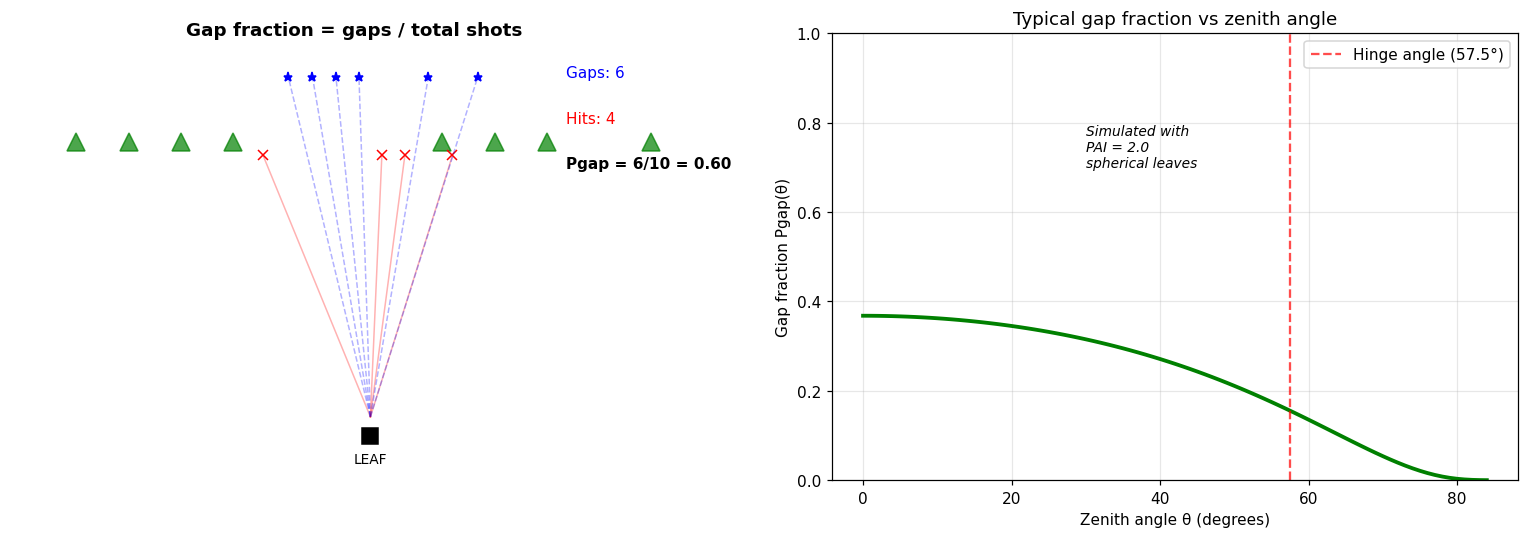

In [6]:
# --- Illustration: gap fraction concept ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: schematic of gap vs hit
ax = axes[0]
ax.set_xlim(-0.5, 10)
ax.set_ylim(-0.5, 6)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Gap fraction = gaps / total shots', fontsize=12, fontweight='bold')

# Scanner at bottom
ax.plot(5, 0, 'ks', ms=10)
ax.text(5, -0.4, 'LEAF', ha='center', fontsize=9)

# Canopy layer
np.random.seed(42)
for x in np.arange(0.5, 10, 0.8):
    if np.random.random() > 0.3:  # 70% canopy cover
        ax.plot(x, 4.5, 'g^', ms=12, alpha=0.7)

# Laser shots
angles = np.linspace(-0.35, 0.35, 10)
hits = 0
gaps = 0
for i, a in enumerate(angles):
    x_top = 5 + 4.5 * np.tan(a)
    is_hit = np.random.random() > 0.35
    if is_hit:
        ax.plot([5, x_top], [0.3, 4.3], 'r-', alpha=0.3, lw=1)
        ax.plot(x_top, 4.3, 'rx', ms=6)
        hits += 1
    else:
        ax.plot([5, x_top], [0.3, 5.5], 'b--', alpha=0.3, lw=1)
        ax.plot(x_top, 5.5, 'b*', ms=6)
        gaps += 1

ax.text(8, 5.5, f'Gaps: {gaps}', color='blue', fontsize=10)
ax.text(8, 4.8, f'Hits: {hits}', color='red', fontsize=10)
ax.text(8, 4.1, f'Pgap = {gaps}/{gaps+hits} = {gaps/(gaps+hits):.2f}', 
        fontsize=10, fontweight='bold')


# RIGHT: typical Pgap(theta) curve
ax = axes[1]
theta_plot = np.arange(0, 85, 1)
# Simulate a typical Pgap curve (Beer-Lambert with PAI=2)
pai_sim = 2.0
G = 0.5  # spherical leaf angle distribution
pgap_sim = np.exp(-pai_sim * G / np.cos(np.deg2rad(theta_plot)))

ax.plot(theta_plot, pgap_sim, 'g-', lw=2.5)
ax.axvline(57.5, color='red', ls='--', alpha=0.7, label='Hinge angle (57.5°)')
ax.set(xlabel='Zenith angle θ (degrees)', ylabel='Gap fraction Pgap(θ)',
       title='Typical gap fraction vs zenith angle', ylim=(0, 1))
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(30, 0.7, f'Simulated with\nPAI = {pai_sim}\nspherical leaves',
        fontsize=9, style='italic')

plt.tight_layout()
plt.show()

---
## 8. From gap fraction to Plant Area Index (PAI)

### What is PAI?

**Plant Area Index** is the total one-sided area of all plant material (leaves, needles, branches) per unit ground area. It is dimensionless (m² plant / m² ground).

- A bare field has **PAI ≈ 0**
- A typical forest might have **PAI = 2–6**
- A dense tropical forest might have **PAI > 8**

PAI is related to gap fraction through the **Beer-Lambert law** — the same law that describes how light is attenuated passing through any medium:

$$P_{gap}(\theta) = e^{-G(\theta) \cdot PAI / \cos(\theta)}$$

where:
- $G(\theta)$ is the **projection coefficient** (how leaves are oriented relative to the beam direction)
- $\cos(\theta)$ accounts for the longer path through the canopy at steeper angles

Rearranging:

$$PAI = \frac{-\ln(P_{gap}(\theta)) \cdot \cos(\theta)}{G(\theta)}$$

### The problem: we need to know G(θ)

The projection coefficient $G(\theta)$ depends on **leaf angle distribution** (are leaves horizontal? vertical? random?). For a **spherical distribution** (leaves oriented equally in all directions), $G = 0.5$ at all angles.

### Miller's formula: integrating over all angles

Rather than relying on $G(\theta)$ at a single angle, Miller (1967) showed that integrating over all zenith angles cancels out the leaf angle dependence:

$$PAI = 2 \int_0^{\pi/2} -\ln(P_{gap}(\theta)) \cdot \cos(\theta) \cdot \sin(\theta) \, d\theta$$

This is the standard method used with **hemispherical scans** — it requires Pgap at many zenith angles but does not require knowing the leaf angle distribution.

In [8]:
# --- Demonstrate PAI estimation from simulated Pgap ---

# Simulate a forest with PAI = 3, spherical leaf distribution
pai_true = 3.0
G = 0.5

theta_deg = np.arange(1, 85, 1)
theta_rad = np.deg2rad(theta_deg)

# Generate Pgap (Beer-Lambert)
pgap = np.exp(-pai_true * G / np.cos(theta_rad))

# Add some noise to simulate real data
np.random.seed(7)
pgap_noisy = pgap + np.random.normal(0, 0.02, len(pgap))
pgap_noisy = np.clip(pgap_noisy, 0.001, 1.0)

# Recover PAI using Miller's formula
integrand = -np.log(pgap_noisy) * np.cos(theta_rad) * np.sin(theta_rad)
pai_recovered = 2 * np.trapezoid(integrand, theta_rad)

print(f"True PAI:      {pai_true:.2f}")
print(f"Recovered PAI: {pai_recovered:.2f} (Miller's formula)")
print(f"Error:         {abs(pai_recovered - pai_true):.3f}")

# Also estimate from hinge angle
idx_57 = np.argmin(np.abs(theta_deg - 57.5))
pai_hinge = -np.log(pgap_noisy[idx_57])
print(f"\nPAI at hinge:  {pai_hinge:.2f} (from single angle at 57.5°)")

True PAI:      3.00
Recovered PAI: 2.66 (Miller's formula)
Error:         0.339

PAI at hinge:  3.35 (from single angle at 57.5°)


---
## 9. The hinge angle trick (57.5°)

This is one of the most elegant ideas in canopy measurement.

### The problem with single-angle estimates
At most zenith angles, the PAI estimate depends on knowing the leaf angle distribution through $G(\theta)$. If the leaves are mostly horizontal vs mostly vertical, the same PAI will produce very different gap fractions at a given angle.

### The solution: θ = 57.5°
Warren-Wilson (1963) showed that at θ ≈ 57.5°, the projection coefficient satisfies:

$$\frac{G(57.5°)}{\cos(57.5°)} \approx 1$$

for **any** leaf angle distribution. This means:

$$PAI \approx -\ln(P_{gap}(57.5°))$$

No need to know whether leaves are horizontal, vertical, or anything in between. This is why the LEAF's hinge scans are centered at 57.5° — it provides a **robust, assumption-free** PAI estimate from a single zenith angle, which can be acquired very quickly (1–5 minutes vs 6–42 minutes for a hemi scan).

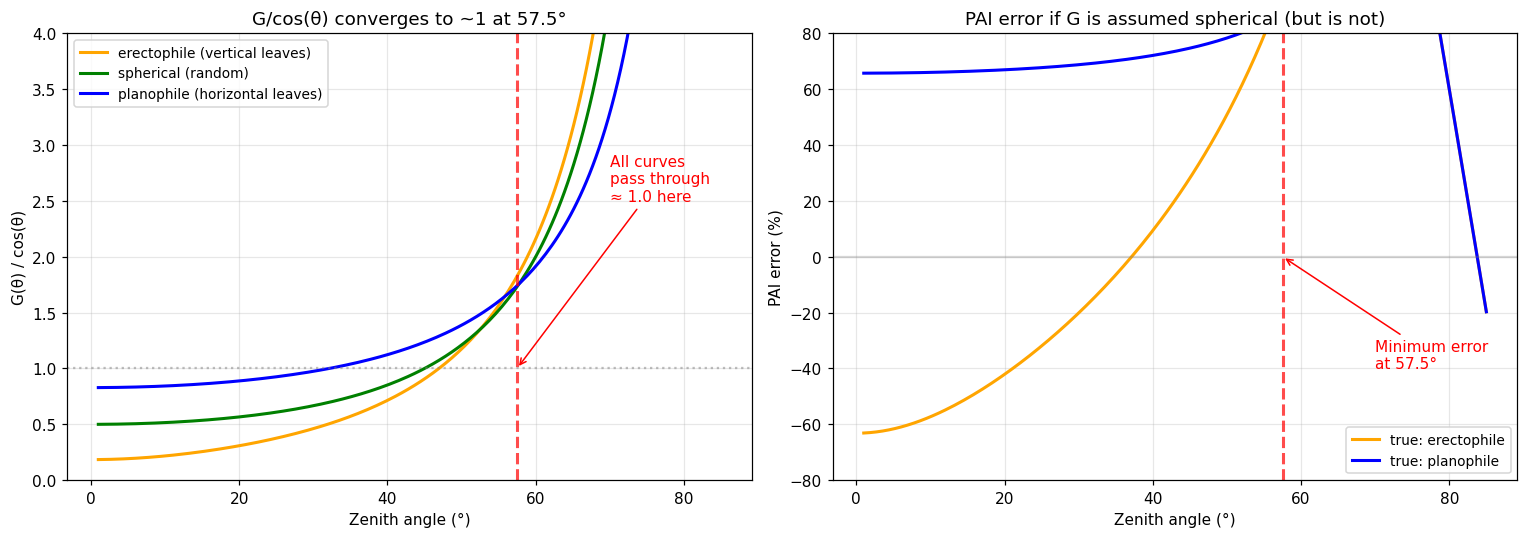

In [9]:
# --- Show why 57.5 deg is special ---

# G(theta) for different leaf angle distributions (Campbell ellipsoidal model)
def G_campbell(theta_rad, chi):
    """Campbell projection coefficient.
    chi: leaf angle distribution parameter.
    chi=1 → spherical, chi>1 → planophile (horizontal), chi<1 → erectophile (vertical)
    """
    # Simplified Campbell model
    num = np.sqrt(chi**2 + np.tan(theta_rad)**2)
    denom = chi + 1.774 * (chi + 1.182)**(-0.733)
    return num / denom

theta_range = np.linspace(1, 85, 200)
theta_range_rad = np.deg2rad(theta_range)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: G(theta)/cos(theta) for different distributions
ax = axes[0]
for chi, label, color in [(0.3, 'erectophile (vertical leaves)', 'orange'),
                           (1.0, 'spherical (random)', 'green'),
                           (3.0, 'planophile (horizontal leaves)', 'blue')]:
    G_vals = G_campbell(theta_range_rad, chi)
    ratio = G_vals / np.cos(theta_range_rad)
    ax.plot(theta_range, ratio, '-', lw=2, color=color, label=label)

ax.axvline(57.5, color='red', ls='--', lw=2, alpha=0.7)
ax.axhline(1.0, color='grey', ls=':', alpha=0.5)
ax.set(xlabel='Zenith angle (°)', ylabel='G(θ) / cos(θ)',
       title='G/cos(θ) converges to ~1 at 57.5°', ylim=(0, 4))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Annotate convergence
ax.annotate('All curves\npass through\n≈ 1.0 here', xy=(57.5, 1.0),
            xytext=(70, 2.5), fontsize=10, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

# RIGHT: PAI error vs zenith angle for wrong G assumption
ax = axes[1]
pai_true = 3.0
for chi_true, label, color in [(0.3, 'true: erectophile', 'orange'),
                                (3.0, 'true: planophile', 'blue')]:
    G_true = G_campbell(theta_range_rad, chi_true)
    pgap = np.exp(-pai_true * G_true / np.cos(theta_range_rad))
    pgap = np.clip(pgap, 1e-6, 1)
    
    # If we assume spherical (G=0.5):
    pai_est = -np.log(pgap) * np.cos(theta_range_rad) / 0.5
    error_pct = (pai_est - pai_true) / pai_true * 100
    ax.plot(theta_range, error_pct, '-', lw=2, color=color, label=label)

ax.axvline(57.5, color='red', ls='--', lw=2, alpha=0.7)
ax.axhline(0, color='grey', ls='-', alpha=0.3)
ax.set(xlabel='Zenith angle (°)', ylabel='PAI error (%)',
       title='PAI error if G is assumed spherical (but is not)', ylim=(-80, 80))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.annotate('Minimum error\nat 57.5°', xy=(57.5, 0),
            xytext=(70, -40), fontsize=10, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

---
## 10. Vertical profiles: PAVD

### From 2D gap fraction to 3D canopy structure

PAI tells us *how much* vegetation there is in total, but not *where* it is vertically. For DE-Har, this vertical information is critical — the pine overstory (14–19 m) and deciduous understory (2–10 m) may respond differently to drought.

**PAVD = Plant Area Volume Density** tells us the density of plant material at each height layer (units: m² plant area per m³ of space).

### How it works

1. For each laser return with range $r$ at zenith angle $\theta$, compute the **height** of the target:

$$h = r \cdot \cos(\theta)$$

2. For each height layer $z$, compute the **gap fraction at height $z$**: the fraction of laser pulses that either had no return at all (sky gap) or had their first return above height $z$ (passed through layer $z$ without being intercepted):

$$P_{gap}(\theta, z) = \frac{N_{\text{gap}} + N_{\text{return above } z}}{N_{\text{total}}}$$

3. The cumulative PAI above height $z$:

$$PAI(z) = -\ln(P_{gap}(z))$$

4. PAVD is the vertical derivative — how much PAI is added per metre of height:

$$PAVD(z) = \frac{dPAI(z)}{dz}$$

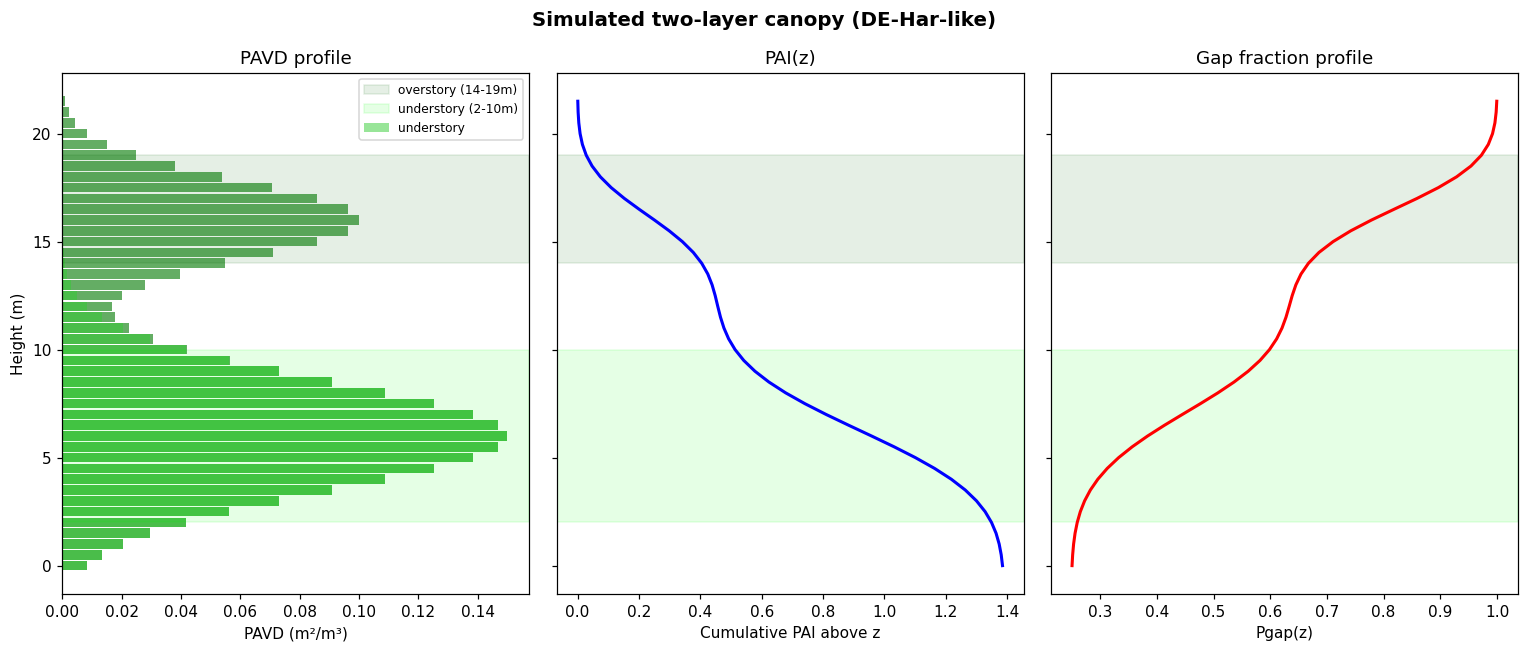

PAI (understory 2-10m):  0.86
PAI (overstory 14-19m): 0.39
PAI (total):            1.39


In [10]:
# --- Simulated PAVD profile for a two-layer canopy like DE-Har ---

heights = np.arange(0, 22, 0.5)

# Simulate two canopy layers with Gaussian density profiles
# Understory: broadleaf, peak at 6m
understory = 0.15 * np.exp(-0.5 * ((heights - 6) / 2.5)**2)
# Overstory: pine, peak at 16m
overstory = 0.10 * np.exp(-0.5 * ((heights - 16) / 1.8)**2)
pavd_sim = understory + overstory

# Cumulative PAI (integrating from top)
pai_cumulative = np.cumsum(pavd_sim[::-1])[::-1] * 0.5  # multiply by bin width

# Pgap from PAI
pgap_profile = np.exp(-pai_cumulative)

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=True)

# PAVD
ax = axes[0]
ax.barh(heights, pavd_sim, height=0.45, color='forestgreen', alpha=0.7)
ax.barh(heights, understory, height=0.45, color='limegreen', alpha=0.5, label='understory')
ax.set(xlabel='PAVD (m²/m³)', ylabel='Height (m)', title='PAVD profile')
ax.axhspan(14, 19, alpha=0.1, color='darkgreen', label='overstory (14-19m)')
ax.axhspan(2, 10, alpha=0.1, color='lime', label='understory (2-10m)')
ax.legend(fontsize=8, loc='upper right')

# Cumulative PAI
ax = axes[1]
ax.plot(pai_cumulative, heights, 'b-', lw=2)
ax.set(xlabel='Cumulative PAI above z', title='PAI(z)')
ax.axhspan(14, 19, alpha=0.1, color='darkgreen')
ax.axhspan(2, 10, alpha=0.1, color='lime')

# Pgap
ax = axes[2]
ax.plot(pgap_profile, heights, 'r-', lw=2)
ax.set(xlabel='Pgap(z)', title='Gap fraction profile')
ax.axhspan(14, 19, alpha=0.1, color='darkgreen')
ax.axhspan(2, 10, alpha=0.1, color='lime')

plt.suptitle('Simulated two-layer canopy (DE-Har-like)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# PAI per layer
pai_understory = np.sum(understory[(heights >= 2) & (heights <= 10)]) * 0.5
pai_overstory = np.sum(overstory[(heights >= 14) & (heights <= 19)]) * 0.5
print(f"PAI (understory 2-10m):  {pai_understory:.2f}")
print(f"PAI (overstory 14-19m): {pai_overstory:.2f}")
print(f"PAI (total):            {np.sum(pavd_sim) * 0.5:.2f}")

---
## 11. Uncertainty and error sources

### 11.1 Range measurement uncertainty
- LEAF range resolution: **1 cm**
- Range accuracy depends on signal strength (drops at long range, in sunlight, or with dirty optics)
- At 905 nm, rain drops, fog, and water on leaves can cause false returns or attenuation

### 11.2 Angular uncertainty
- **Scan encoder**: 25,600 counts / 360° = **0.014° per count** → negligible angular error from encoder quantization
- **Rotary encoder**: 20,000 counts / 360° = **0.018° per count** → also negligible
- Main angular uncertainty comes from **tilt of the scanner** (if the tripod shifts or the ground settles)
- LEAF has a tilt sensor: ±1024 counts = ±90° → resolution of ~0.09° per count

### 11.3 Beam divergence effects
- A wide beam at long range may partially hit a target → **partial returns** with reduced intensity
- Partial hits are ambiguous: is it a gap or a hit? Binary gap/hit classification (which is what Pgap uses) may misclassify partial hits
- Effect is larger for the overstory (further away) than understory

### 11.4 Optical fouling
- Dust, spider webs, algae, condensation on the laser optics reduce signal strength
- Manifests as a **gradual decline in apparent canopy height and PAI** over weeks/months
- **Must be tracked** in time series and corrected via maintenance records

### 11.5 Environmental effects

| Factor | Effect on data | Mitigation |
|--------|---------------|-------------|
| **Rain** | Water drops on canopy → false returns, inflated PAI | Flag via collocated met data; schedule scans at night |
| **Wind** | Moving canopy → smearing of returns, noise in Pgap | Check scan-to-scan variability; rolling median filter |
| **Temperature** | Lidar electronics affected at extremes; motor may overshoot | Monitor enclosure temp; motor temp < 65°C |
| **Sunlight** | 905 nm solar background degrades signal-to-noise | Night scans strongly preferred |
| **Dew/frost** | Condensation on optics or on foliage | Monitor enclosure RH; predawn scans may be affected |

### 11.6 Clumping
- Real canopies are not random — leaves clump in crowns, along branches, etc.
- Clumping means light (or laser pulses) preferentially penetrates through inter-crown gaps rather than through foliage
- This causes **overestimation of gap fraction** → **underestimation of PAI**
- The hinge angle method and Miller's formula both assume random foliage distribution
- Clumping correction is possible but requires additional analysis (not covered here)

### 11.7 Wood area
- PAI includes **all** plant material: leaves + branches + trunks
- Strictly, **LAI** (leaf area only) = PAI × (1 − α), where α = wood-to-total plant area ratio
- For Scots pine at DE-Har, this distinction matters — especially during drought when leaf loss occurs but wood remains

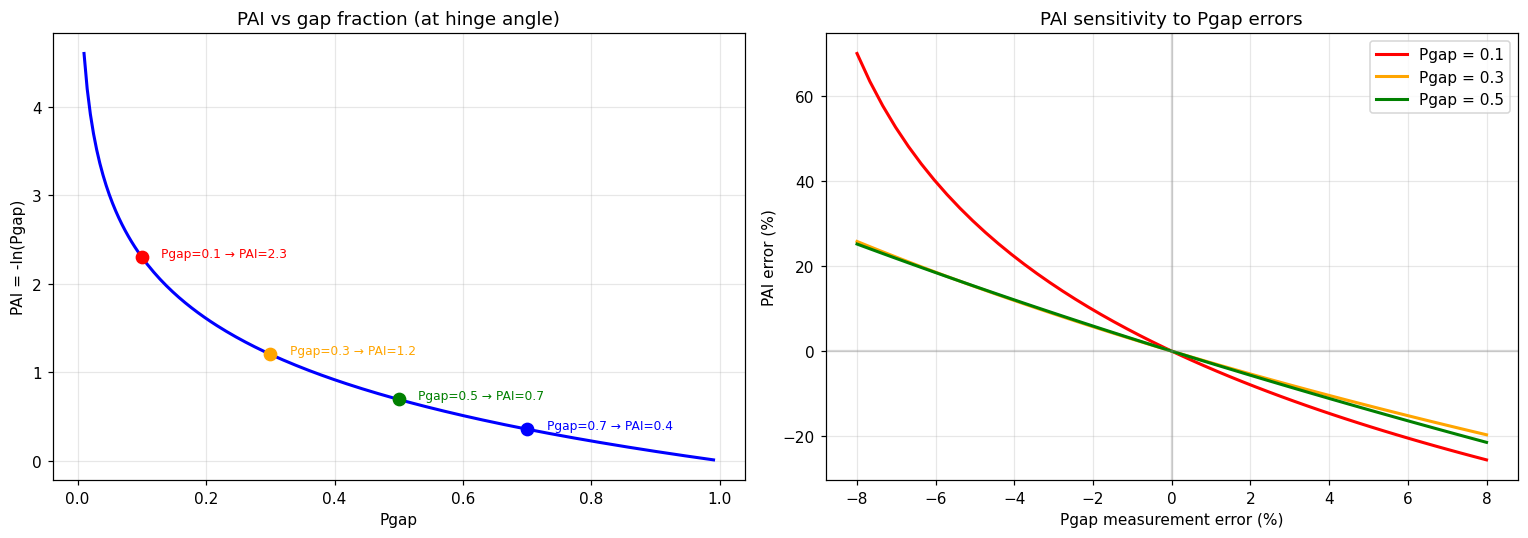

Key insight: PAI is MORE sensitive to Pgap errors when Pgap is LOW (dense canopy).
This is because -ln(x) has a steep slope near x=0.
At Pgap=0.1, a 5% error in Pgap → ~25% error in PAI.
At Pgap=0.5, a 5% error in Pgap → ~7% error in PAI.


In [11]:
# --- Sensitivity: how much does Pgap error affect PAI? ---

pgap_range = np.linspace(0.01, 0.99, 200)
pai_from_pgap = -np.log(pgap_range)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: PAI = -ln(Pgap) relationship
ax = axes[0]
ax.plot(pgap_range, pai_from_pgap, 'b-', lw=2)
ax.set(xlabel='Pgap', ylabel='PAI = -ln(Pgap)',
       title='PAI vs gap fraction (at hinge angle)')
ax.grid(True, alpha=0.3)

# Mark example values
for pg, c in [(0.1, 'red'), (0.3, 'orange'), (0.5, 'green'), (0.7, 'blue')]:
    p = -np.log(pg)
    ax.plot(pg, p, 'o', color=c, ms=8)
    ax.text(pg + 0.03, p, f'Pgap={pg} → PAI={p:.1f}', fontsize=8, color=c)

# RIGHT: PAI sensitivity to Pgap error
ax = axes[1]
# If true Pgap = 0.3, what happens if we're off by ±0.05?
for pgap_true, color in [(0.1, 'red'), (0.3, 'orange'), (0.5, 'green')]:
    errors = np.linspace(-0.08, 0.08, 50)
    pgap_measured = pgap_true + errors
    pgap_measured = np.clip(pgap_measured, 0.01, 0.99)
    pai_true = -np.log(pgap_true)
    pai_measured = -np.log(pgap_measured)
    pai_error_pct = (pai_measured - pai_true) / pai_true * 100
    ax.plot(errors * 100, pai_error_pct, '-', color=color, lw=2,
            label=f'Pgap = {pgap_true}')

ax.set(xlabel='Pgap measurement error (%)', ylabel='PAI error (%)',
       title='PAI sensitivity to Pgap errors')
ax.axhline(0, color='grey', ls='-', alpha=0.3)
ax.axvline(0, color='grey', ls='-', alpha=0.3)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key insight: PAI is MORE sensitive to Pgap errors when Pgap is LOW (dense canopy).")
print("This is because -ln(x) has a steep slope near x=0.")
print("At Pgap=0.1, a 5% error in Pgap → ~25% error in PAI.")
print("At Pgap=0.5, a 5% error in Pgap → ~7% error in PAI.")

---
## 12. Glossary

| Term | Definition |
|------|------------|
| **Azimuth** | Horizontal angle (compass direction), 0–360° |
| **Beam divergence** | Angular spread of the laser beam (LEAF: 0.3°) |
| **Encoder** | Internal position sensor that records motor position as integer counts |
| **FAVD / PAVD** | Foliage / Plant Area Volume Density — density of plant material at a given height (m²/m³) |
| **First return** | Range to the nearest object detected by a laser pulse |
| **Gap** | A laser pulse that does not hit any object (range = −1 or > 120 m) — sky is visible |
| **Gap fraction (Pgap)** | Fraction of laser pulses in a zenith ring that are gaps; probability of seeing sky |
| **G(θ)** | Projection coefficient; describes how leaf orientation affects interception probability |
| **Hinge angle** | 57.5° zenith — the angle where PAI estimation is insensitive to leaf angle distribution |
| **Intensity** | Strength of reflected laser signal (0–100, uncalibrated, not range-corrected) |
| **LAI** | Leaf Area Index — PAI minus wood area contribution |
| **Last return** | Range to the furthest object detected (beam may penetrate past the first object) |
| **Miller's formula** | Integration method to compute PAI from gap fraction at multiple zenith angles |
| **PAI** | Plant Area Index — total one-sided area of plant material per unit ground area (m²/m²) |
| **Range** | Distance from scanner to target (metres), measured by time-of-flight of laser pulse |
| **Rotary encoder** | Encoder tracking azimuth position (20,000 counts / 360° on LEAF MkIII) |
| **Scan encoder** | Encoder tracking zenith position (25,600 counts / 360° on LEAF MkIII) |
| **TLS** | Terrestrial Laser Scanner — ground-based lidar for 3D mapping |
| **Zenith** | The direction straight up; zenith angle = 0° means pointing straight up, 90° = horizon |
| **Zenith ring** | All measurements at the same zenith angle (across all azimuths) |

### Key references
- **Jupp et al. (2009)** — Estimating forest LAI profiles and structural parameters using a ground-based laser. *Tree Physiology* 29(2), 171–181.
- **Calders et al. (2014)** — Implications of sensor configuration and topography on vertical plant profiles. *Agricultural and Forest Meteorology* 194, 104–117.
- **Campbell (1986)** — Extinction coefficients for radiation in plant canopies. *Agricultural and Forest Meteorology* 36, 317–321.
- **Warren-Wilson (1963)** — Estimation of foliage denseness and foliage angle by inclined point quadrats. *Australian Journal of Botany* 11, 95–105.
- **Culvenor et al. (2014)** — Automated in-situ laser scanner for monitoring forest leaf area index. *Sensors* 14(8), 14994–15008.